# Cognifyz Data Science Internship
## Level 3 - Task 2: Customer Preference Analysis

### Objective

Analyze customer preferences based on cuisine types, restaurant ratings, and votes.

### Analysis

- Analyze the relationship between cuisine types and restaurant ratings.
- Identify the most popular cuisines based on votes.
- Identify cuisines associated with higher average ratings.
- Visualize the findings.


### Import libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
df = pd.read_csv("Cleaned_Dataset.csv")

required_columns = [
    "Cuisines",
    "Aggregate rating",
    "Votes"
]

print("Required columns:")
display(df[required_columns].head())

print("\nMissing values:")
display(df[required_columns].isnull().sum())

Required columns:


,Cuisines,Aggregate rating,Votes
0,"French, Japanese, Desserts",4.8,314
1,Japanese,4.5,591
2,"Seafood, Asian, Filipino, Indian",4.4,270
3,"Japanese, Sushi",4.9,365
4,"Japanese, Korean",4.8,229



Missing values:


Cuisines            0
Aggregate rating    0
Votes               0
dtype: int64

### Split multiple cuisines and create one row per cuisine

In [18]:
cuisine_df = df.assign(
    Cuisine=df["Cuisines"].str.split(", ")
).explode("Cuisine")

print("Cuisine analysis dataset created successfully!")
print("Number of cuisine entries:", len(cuisine_df))

display(cuisine_df[["Cuisine", "Aggregate rating", "Votes"]].head(10))

Cuisine analysis dataset created successfully!
Number of cuisine entries: 19719


,Cuisine,Aggregate rating,Votes
0,French,4.8,314
0,Japanese,4.8,314
0,Desserts,4.8,314
1,Japanese,4.5,591
2,Seafood,4.4,270
2,Asian,4.4,270
2,Filipino,4.4,270
2,Indian,4.4,270
3,Japanese,4.9,365
3,Sushi,4.9,365


### Calculate average rating by cuisine

In [19]:
cuisine_rating = (
    cuisine_df
    .groupby("Cuisine")["Aggregate rating"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

cuisine_rating.columns = [
    "Restaurant Count",
    "Average Rating"
]

print("Cuisine-wise average ratings:")
display(cuisine_rating.head(15))

Cuisine-wise average ratings:


,Restaurant Count,Average Rating
Cuisine,,
Sunda,3,4.900000
B�_rek,1,4.700000
Taiwanese,2,4.650000
Ramen,2,4.500000
Dim Sum,3,4.466667
Hawaiian,8,4.412500
Bubble Tea,1,4.400000
D�_ner,1,4.400000
Curry,6,4.400000


In [20]:
cuisine_rating_filtered = (
    cuisine_rating[cuisine_rating["Restaurant Count"] >= 20]
    .sort_values("Average Rating", ascending=False)
)

print("Cuisines with at least 20 restaurants:")
display(cuisine_rating_filtered.head(15))

Cuisines with at least 20 restaurants:


,Restaurant Count,Average Rating
Cuisine,,
International,21,4.247619
Southern,24,4.129167
Vegetarian,23,4.073913
Sandwich,53,4.066038
Grill,21,4.057143
Steak,62,3.985484
Sushi,75,3.973333
Goan,20,3.970000
Breakfast,41,3.965854


### Visualize average ratings

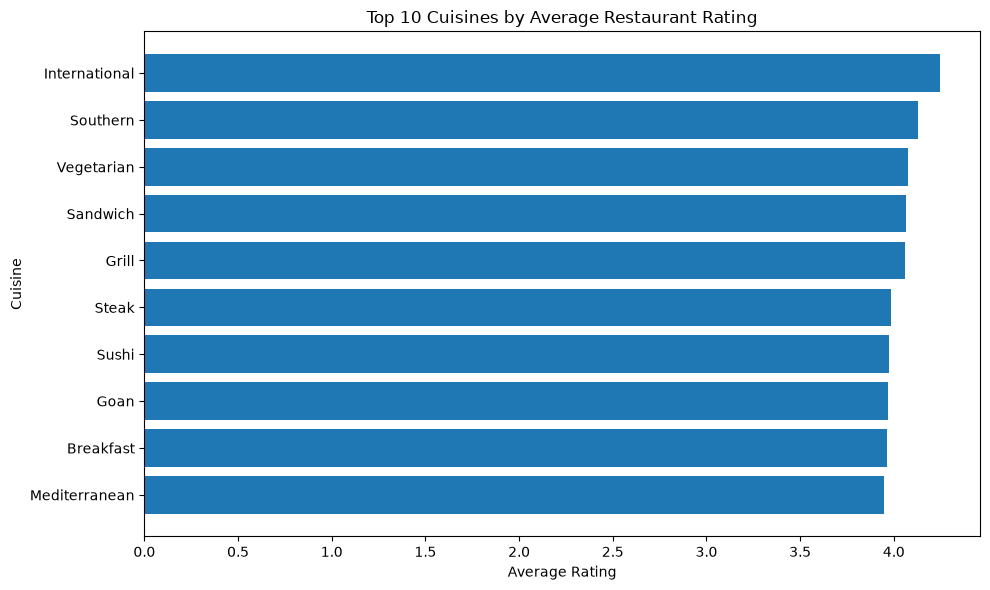

In [21]:
top_cuisines_rating = cuisine_rating_filtered.head(10).sort_values(
    "Average Rating"
)

plt.figure(figsize=(10, 6), dpi=100)

plt.barh(
    top_cuisines_rating.index,
    top_cuisines_rating["Average Rating"]
)

plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.title("Top 10 Cuisines by Average Restaurant Rating")

plt.tight_layout()
plt.show()

### Calculate total votes by cuisine

In [22]:
cuisine_votes = (
    cuisine_df
    .groupby("Cuisine")["Votes"]
    .agg(["count", "sum", "mean"])
    .sort_values("sum", ascending=False)
)

cuisine_votes.columns = [
    "Restaurant Count",
    "Total Votes",
    "Average Votes"
]

print("Cuisine popularity based on total votes:")
display(cuisine_votes.head(15))

Cuisine popularity based on total votes:


,Restaurant Count,Total Votes,Average Votes
Cuisine,,,
North Indian,3969,598707,150.845805
Chinese,2735,364351,133.217916
Italian,764,329265,430.975131
Continental,736,288255,391.650815
Fast Food,1986,184058,92.677744
American,390,183117,469.530769
Cafe,703,177568,252.586060
Mughlai,995,151946,152.709548
Desserts,653,105889,162.157734


### Filter cuisines with enough restaurants

In [23]:
cuisine_votes_filtered = (
    cuisine_votes[cuisine_votes["Restaurant Count"] >= 20]
    .sort_values("Total Votes", ascending=False)
)

print("Most popular cuisines based on total votes:")
display(cuisine_votes_filtered.head(15))

Most popular cuisines based on total votes:


,Restaurant Count,Total Votes,Average Votes
Cuisine,,,
North Indian,3969,598707,150.845805
Chinese,2735,364351,133.217916
Italian,764,329265,430.975131
Continental,736,288255,391.650815
Fast Food,1986,184058,92.677744
American,390,183117,469.530769
Cafe,703,177568,252.586060
Mughlai,995,151946,152.709548
Desserts,653,105889,162.157734


### Visualize the most popular cuisines

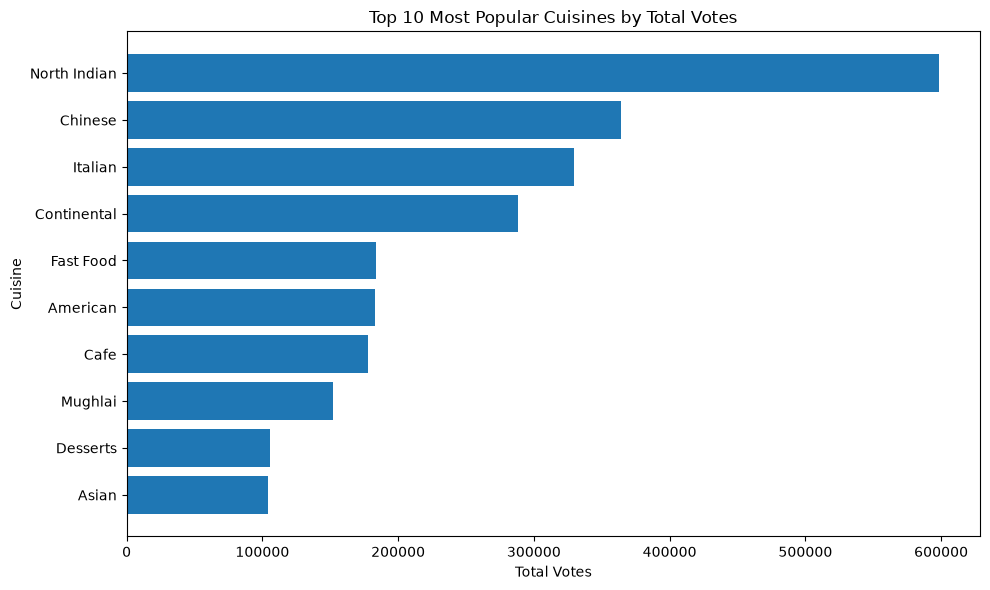

In [24]:
top_cuisines_votes = (
    cuisine_votes_filtered
    .head(10)
    .sort_values("Total Votes")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_cuisines_votes.index,
    top_cuisines_votes["Total Votes"]
)

plt.xlabel("Total Votes")
plt.ylabel("Cuisine")
plt.title("Top 10 Most Popular Cuisines by Total Votes")

plt.tight_layout()
plt.show()

### Identify cuisines associated with higher ratings

In [25]:
top_rated_cuisines = (
    cuisine_rating_filtered
    .head(10)
    .sort_values("Average Rating")
)

print("Top cuisines by average rating:")
display(top_rated_cuisines)

Top cuisines by average rating:


,Restaurant Count,Average Rating
Cuisine,,
Mediterranean,112,3.948214
Breakfast,41,3.965854
Goan,20,3.970000
Sushi,75,3.973333
Steak,62,3.985484
Grill,21,4.057143
Sandwich,53,4.066038
Vegetarian,23,4.073913
Southern,24,4.129167


### Visualize higher-rated cuisines

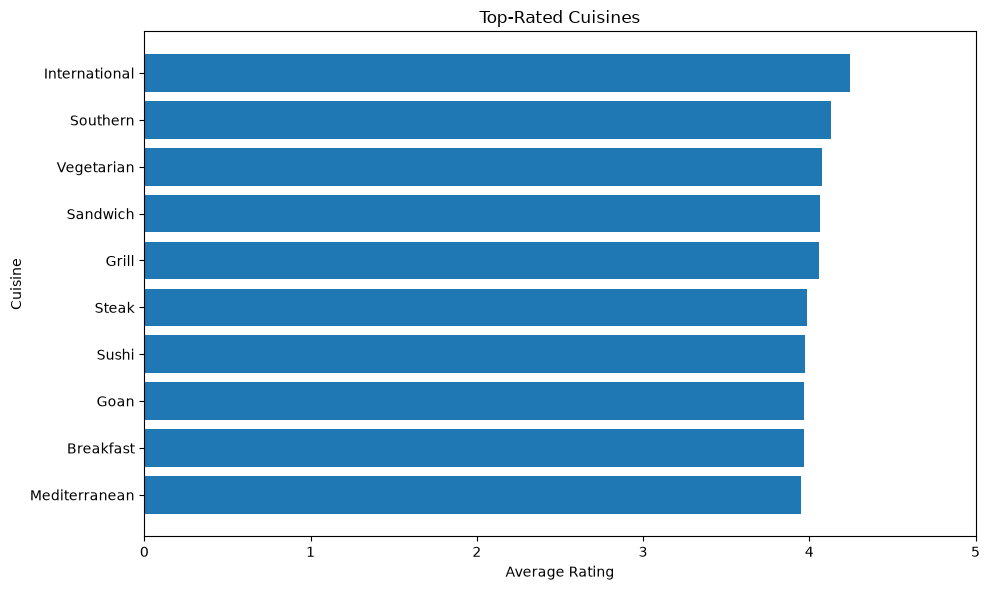

In [26]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_rated_cuisines.index,
    top_rated_cuisines["Average Rating"]
)

plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.title("Top-Rated Cuisines")

plt.xlim(0, 5)
plt.tight_layout()
plt.show()

### Compare popularity and rating

In [27]:
cuisine_summary = pd.merge(
    cuisine_rating_filtered,
    cuisine_votes_filtered,
    left_index=True,
    right_index=True,
    suffixes=("_Rating", "_Votes")
)

cuisine_summary = cuisine_summary[
    [
        "Restaurant Count_Rating",
        "Average Rating",
        "Total Votes",
        "Average Votes"
    ]
].sort_values(
    "Average Rating",
    ascending=False
)

print("Cuisine preference summary:")
display(cuisine_summary.head(15))

Cuisine preference summary:


,Restaurant Count_Rating,Average Rating,Total Votes,Average Votes
Cuisine,,,,
International,21,4.247619,8122,386.761905
Southern,24,4.129167,13939,580.791667
Vegetarian,23,4.073913,10714,465.826087
Sandwich,53,4.066038,23500,443.396226
Grill,21,4.057143,4301,204.809524
Steak,62,3.985484,25677,414.145161
Sushi,75,3.973333,20582,274.426667
Goan,20,3.970000,11488,574.400000
Breakfast,41,3.965854,16097,392.609756


### Create a concise results table

In [28]:
final_results = pd.DataFrame({
    "Analysis": [
        "Highest average-rated cuisine",
        "Most voted cuisine",
        "Highest average votes per restaurant"
    ],
    "Result": [
        cuisine_rating_filtered["Average Rating"].idxmax(),
        cuisine_votes_filtered["Total Votes"].idxmax(),
        cuisine_votes_filtered["Average Votes"].idxmax()
    ],
    "Value": [
        round(cuisine_rating_filtered["Average Rating"].max(), 2),
        int(cuisine_votes_filtered["Total Votes"].max()),
        round(cuisine_votes_filtered["Average Votes"].max(), 2)
    ]
})

display(final_results)

,Analysis,Result,Value
0,Highest average-rated cuisine,International,4.25
1,Most voted cuisine,North Indian,598707.00
2,Highest average votes per restaurant,Mediterranean,719.09
